In [ ]:
!pip install -q transformers torch torchvision pillow scikit-learn matplotlib

In [ ]:
from google.colab import files
files = files.upload()

Saving Maxar_post_20241010_TreasureIsland_preview.png to Maxar_post_20241010_TreasureIsland_preview.png
Saving Maxar_pre_20231104_TreasureIsland_preview.png to Maxar_pre_20231104_TreasureIsland_preview.png
Saving NOAA_postHelene_20240930_TreasureIsland_preview.png to NOAA_postHelene_20240930_TreasureIsland_preview.png
Saving NOAA_postMilton_20241011_TreasureIsland_preview.png to NOAA_postMilton_20241011_TreasureIsland_preview.png
Saving S2_post_20241014_preview.png to S2_post_20241014_preview.png
Saving S2_pre_20240919_preview.png to S2_pre_20240919_preview.png


In [ ]:
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
import numpy as np

model.train() = training mode (dropout active, batch stats used).

model.eval() = inference mode (dropout off, fixed stats used).

In [ ]:
MODEL_NAME = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(MODEL_NAME)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)
model.eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05, eleme

In [ ]:
PAIRS = {
    "Maxar (Pre-Nov2023 vs Post-Oct2024)": (
        "Maxar_pre_20231104_TreasureIsland_preview.png",
        "Maxar_post_20241010_TreasureIsland_preview.png",
    ),
    "NOAA (Post-Helene vs Post-Milton)": (
        "NOAA_postHelene_20240930_TreasureIsland_preview.png",
        "NOAA_postMilton_20241011_TreasureIsland_preview.png",
    ),
    "Sentinel-2 (Pre-Sep2024 vs Post-Oct2024)": (
        "S2_pre_20240919_preview.png",
        "S2_post_20241014_preview.png",
    )
}

In [ ]:
def get_clip_embedding(image: Image.Image) -> np.ndarray:
    """Extract a normalized CLIP image embedding."""
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model.get_image_features(**inputs)
        features = outputs.pooler_output
    features = features / features.norm(p=2, dim=-1, keepdim=True)
    return features.numpy().flatten()

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b))

def split_into_patches(image: Image.Image, grid=4):
    """Split an image into grid x grid patches for localized comparison."""
    w, h = image.size
    pw, ph = w // grid, h // grid
    patches, coords = [], []
    for i in range(grid):
        for j in range(grid):
            box = (j * pw, i * ph, (j + 1) * pw, (i + 1) * ph)
            patches.append(image.crop(box))
            coords.append((i, j))
    return patches, coords

In [ ]:
results = {}

for pair_name, (path_a, path_b) in PAIRS.items():
    print(f"\nProcessing: {pair_name}")
    img_a = Image.open(path_a).convert("RGB")
    img_b = Image.open(path_b).convert("RGB")

    # Whole-image similarity
    emb_a = get_clip_embedding(img_a)
    emb_b = get_clip_embedding(img_b)
    whole_sim = cosine_sim(emb_a, emb_b)
    print(f"  Whole-image cosine similarity: {whole_sim:.4f}")

    # Patch-level similarity (resize both to same size first)
    common_size = (1024, 1024)
    img_a_r = img_a.resize(common_size)
    img_b_r = img_b.resize(common_size)

    patches_a, coords = split_into_patches(img_a_r, grid=4)
    patches_b, _ = split_into_patches(img_b_r, grid=4)

    patch_sims = []
    for pa, pb in zip(patches_a, patches_b):
        ea = get_clip_embedding(pa)
        eb = get_clip_embedding(pb)
        patch_sims.append(cosine_sim(ea, eb))

    patch_sims_grid = np.array(patch_sims).reshape(4, 4)

    results[pair_name] = {
        "whole_similarity": whole_sim,
        "patch_grid": patch_sims_grid,
        "img_a": img_a,
        "img_b": img_b,
    }

print("\nAll pairs processed.")


Processing: Maxar (Pre-Nov2023 vs Post-Oct2024)
  Whole-image cosine similarity: 0.9278

Processing: NOAA (Post-Helene vs Post-Milton)
  Whole-image cosine similarity: 0.9589

Processing: Sentinel-2 (Pre-Sep2024 vs Post-Oct2024)
  Whole-image cosine similarity: 0.8691

All pairs processed.


In [ ]:
print(f"  Patch similarity grid:\n{patch_sims_grid}")
# Prints the matrix of Maxar

  Patch similarity grid:
[[0.97723973 0.95921302 0.76271987 0.79937428]
 [0.90822959 0.91501641 0.87338448 0.96134675]
 [0.86993933 0.91120017 0.83737987 0.864088  ]
 [0.92565894 0.945297   0.90502053 0.87633228]]


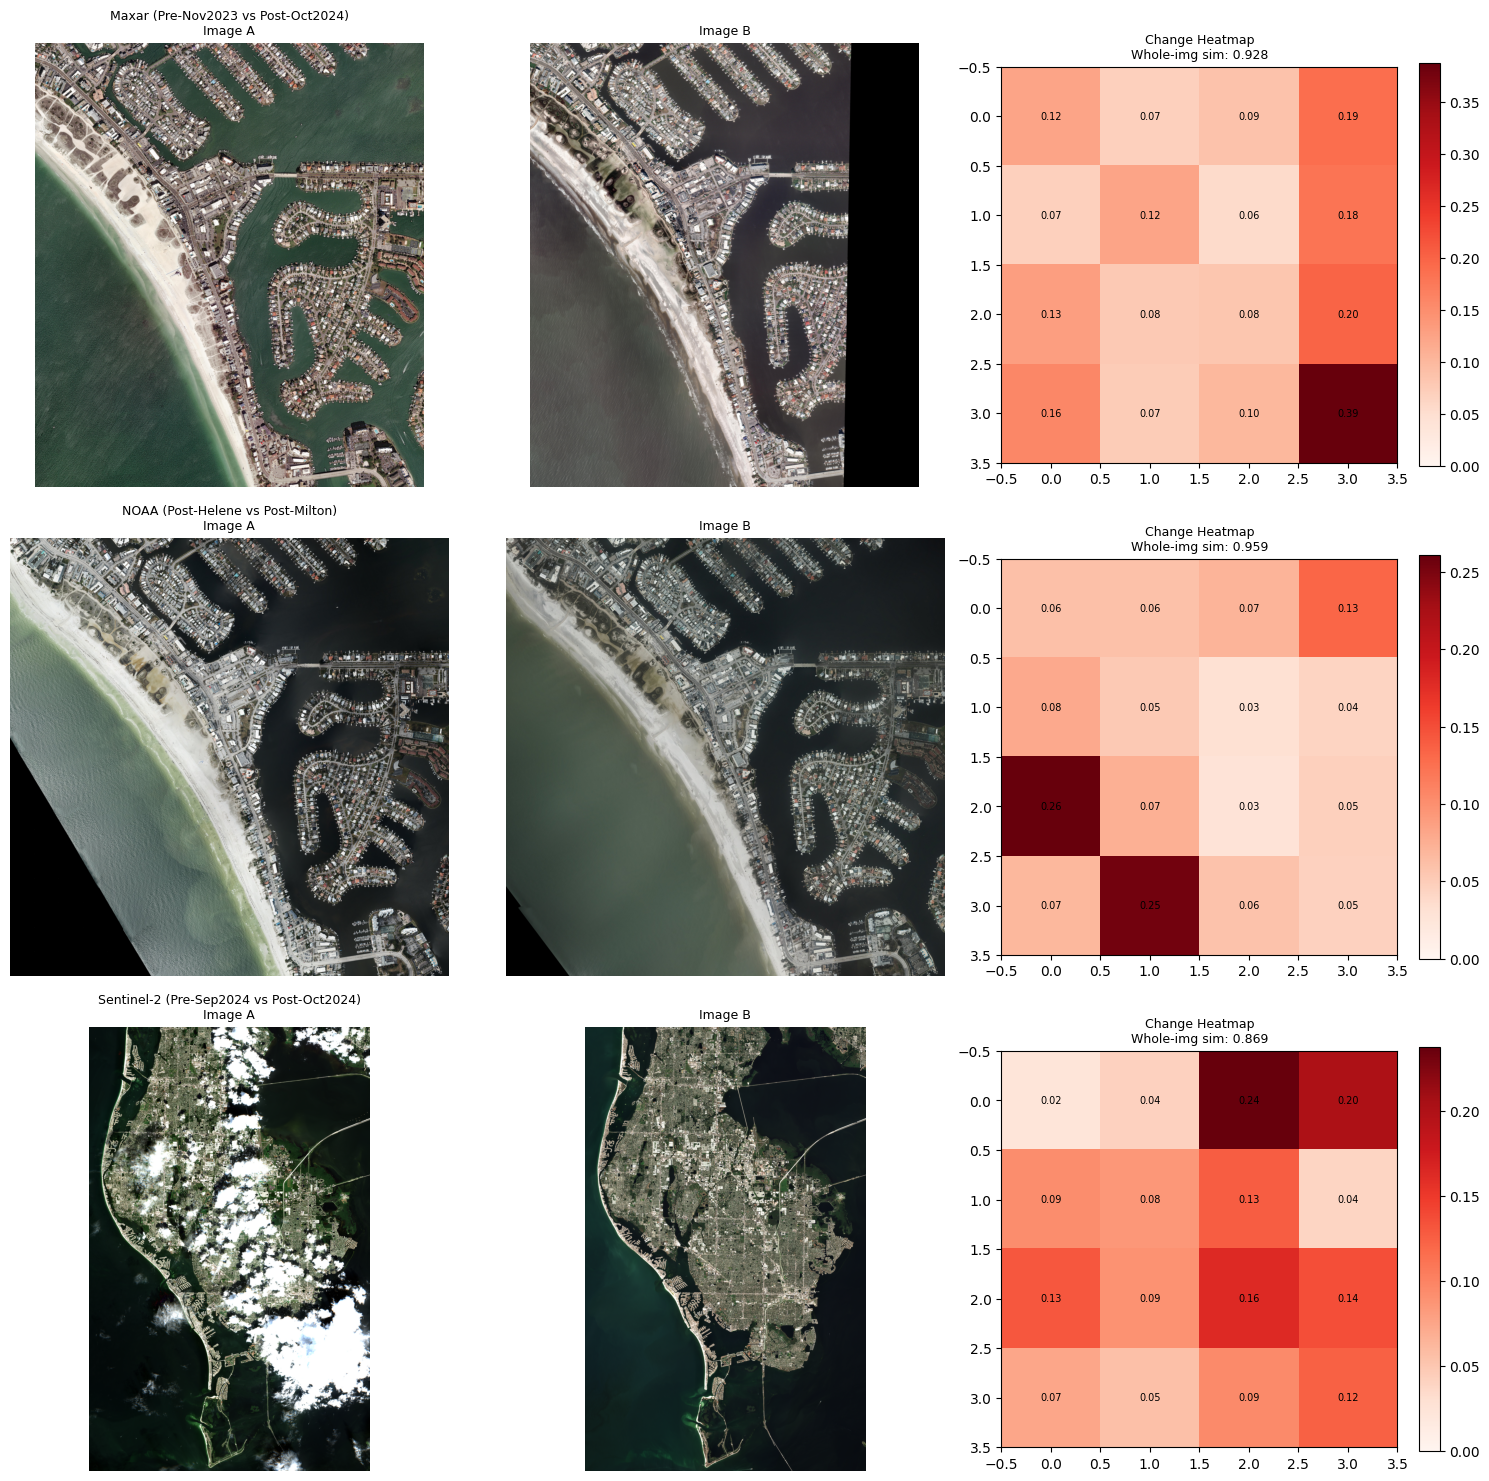

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(results), 3, figsize=(15, 5 * len(results)))

for row, (pair_name, data) in enumerate(results.items()):
    ax_pre, ax_post, ax_heat = axes[row]

    ax_pre.imshow(data["img_a"])
    ax_pre.set_title(f"{pair_name}\nImage A", fontsize=9)
    ax_pre.axis("off")

    ax_post.imshow(data["img_b"])
    ax_post.set_title("Image B", fontsize=9)
    ax_post.axis("off")

    # 1 - similarity = "change" heatmap (higher = more visual change)
    change_grid = 1 - data["patch_grid"]
    im = ax_heat.imshow(change_grid, cmap="Reds", vmin=0, vmax=change_grid.max())
    ax_heat.set_title(f"Change Heatmap\nWhole-img sim: {data['whole_similarity']:.3f}", fontsize=9)
    plt.colorbar(im, ax=ax_heat, fraction=0.046)

    for i in range(4):
        for j in range(4):
            ax_heat.text(j, i, f"{change_grid[i,j]:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.savefig("clip_similarity_results.png", dpi=150, bbox_inches="tight")
plt.show()